# COMP5318 Assignment 1: Rice Classification

##### Group number: 74
##### Student 1 SID: 550175951

## **1. Data Pre-processing**

In [1]:
# Import all libraries
import numpy as np 
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import  MinMaxScaler
from sklearn.model_selection import StratifiedKFold

In [2]:
# Ignore future warnings
from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)

In [4]:
# import os
# os.chdir(r'c:\Users\HP\OneDrive - The University of Sydney (Students)\Desktop\semester 3\COMP4318 & COMP5318\Assignment 1')
# Load the rice dataset: rice-final2.csv
df = pd.read_csv("rice-final2.csv", na_values="?")
df.isnull().sum()
df.shape
df.head()

,Area,Perimiter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,class
0,12573.0,461.466003,192.903351,84.572075,0.898772,12893.0,0.550433,class2
1,12845.0,464.121002,194.332214,85.524338,0.897952,13125.0,0.774962,class2
2,14055.0,488.748993,207.751755,87.250328,0.907536,14484.0,0.550076,class1
3,14412.0,490.324005,207.476135,89.689514,0.901735,14703.0,0.598853,class1
4,14658.0,477.117004,189.566635,99.997780,0.849551,15048.0,0.649504,class2


In [7]:
# Pre-process dataset

X = df.iloc[:,:-1]
y = df.iloc[:,-1]

# Fixing missing values by replacing the missing values with the mean of the column
imputer = SimpleImputer( missing_values = np.nan , strategy="mean")
X = imputer.fit_transform(X)

# Normalize between 0 and 1

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Change Class 1 to 0 and Class 2 to 1
y = np.where(y=="class1" ,0, 1)

print(X.shape)
print(y.shape)


(1400, 7)
(1400,)


In [8]:
# Print first ten rows of pre-processed dataset to 4 decimal places as per assignment spec
# A function is provided to assist

def print_data(X, y, n_rows=10):
    """Takes a numpy data array and target and prints the first ten rows.
    
    Arguments:
        X: numpy array of shape (n_examples, n_features)
        y: numpy array of shape (n_examples)
        n_rows: numpy of rows to print
    """
    for example_num in range(n_rows):
        for feature in X[example_num]:
            print("{:.4f}".format(feature), end=",")

        if example_num == len(X)-1:
            print(y[example_num],end="")
        else:
            print(y[example_num])
            


In [9]:
print_data(X,y)

0.4628,0.5406,0.5113,0.4803,0.7380,0.4699,0.1196,1
0.4900,0.5547,0.5266,0.5018,0.7319,0.4926,0.8030,1
0.6109,0.6847,0.6707,0.5409,0.8032,0.6253,0.1185,0
0.6466,0.6930,0.6677,0.5961,0.7601,0.6467,0.2669,0
0.6712,0.6233,0.4755,0.8293,0.3721,0.6803,0.4211,1
0.2634,0.2932,0.2414,0.4127,0.5521,0.2752,0.2825,1
0.8175,0.9501,0.9515,0.5925,0.9245,0.8162,0.0000,0
0.3174,0.3588,0.3601,0.3908,0.6921,0.3261,0.8510,1
0.3130,0.3050,0.2150,0.5189,0.3974,0.3159,0.4570,1
0.5120,0.5237,0.4409,0.6235,0.5460,0.5111,0.3155,1


## **2. Build Classifiers**

- Part 1:  Logistic Regression, Naïve Bayes
- Part 2:  KNN, Decision Tree, Ada Boost, Gradient Boost, Random Forest, SVM

### Part 1: Cross-validation without parameter tuning

In [10]:
## Setting the 10 fold stratified cross-validation
cvKFold=StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

# The stratified folds from cvKFold should be provided to the classifiers

In [11]:
print(set(y))

{np.int64(0), np.int64(1)}


In [12]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

lr_model = LogisticRegression(random_state=0 , max_iter = 1000)

lr_scores = cross_val_score( lr_model, X, y , cv=cvKFold, scoring="accuracy")
lr_mean = lr_scores.mean()
print(lr_scores)
print("LogR average cross-validation accuracy: {:.4f}".format(lr_mean))

[0.91428571 0.93571429 0.96428571 0.94285714 0.95       0.92857143
 0.94285714 0.95       0.89285714 0.96428571]
LogR average cross-validation accuracy: 0.9386


In [13]:
# Naïve Bayes

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
nb_model =GaussianNB()
nb_scores = cross_val_score(nb_model, X, y, cv= cvKFold, scoring= "accuracy")

nb_mean = nb_scores.mean()

print(nb_scores)
print("NB average cross-validation accuracy: {:.4f}".format(nb_mean))


[0.9        0.92857143 0.95714286 0.91428571 0.94285714 0.93571429
 0.94285714 0.94285714 0.86428571 0.93571429]
NB average cross-validation accuracy: 0.9264


### Part 1 Results


In [14]:
# Print results for each classifier in part 1 to 4 decimal places here:
print("LogR average cross-validation accuracy: {:.4f}".format(lr_mean))
print("NB average cross-validation accuracy: {:.4f}".format(nb_mean))

LogR average cross-validation accuracy: 0.9386
NB average cross-validation accuracy: 0.9264


### Part 2: Cross-validation with parameter tuning

In [15]:
# KNN 
# parameters you may consider
k = [1, 3, 5, 7]
p = [1, 2]


In [16]:
# Decision Tree 
# parameters you may consider
max_depth = [3, 5, 7, 10]
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4]

In [17]:
# Ada Boost
# parameters you may consider
n_estimators = [50, 100, 150]
learning_rate = [0.1, 0.2, 0.3, 0.5]

In [18]:
# Gradient Boost
# parameters you may consider
max_depth = [1, 3, 5, 7]
n_estimators = [50, 100, 150]
learning_rate = [0.1, 0.2, 0.3, 0.5]

In [19]:
# Random Forest
# You should use RandomForestClassifier from sklearn.ensemble with information gain and max_features set to ‘sqrt’.
# parameters you may consider
n_estimators = [10, 30, 60, 100]
max_leaf_nodes = [6, 12]



In [20]:
# SVM
# parameters you may consider
C = [0.01, 0.1, 1, 5]
gamma = [0.01, 0.1, 1, 10]
# optional
kernel = []


### Part 2: Results

In [21]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, f1_score

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)

gb_params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.1, 0.2, 0.3, 0.5],
    'max_depth': [1, 3, 5, 7],
}

gb_search = GridSearchCV(
    GradientBoostingClassifier(random_state=0),
    gb_params,
    cv=cvKFold,
    scoring='accuracy',
    n_jobs=-1,
)
gb_search.fit(X_train, y_train)
best_gb = gb_search.best_estimator_

print('Gradient Boost best params:', gb_search.best_params_)
print('Gradient Boost CV accuracy: {:.4f}'.format(gb_search.best_score_))

y_val_gb = best_gb.predict(X_val)
print('Gradient Boost validation accuracy: {:.4f}'.format(accuracy_score(y_val, y_val_gb)))
print('Gradient Boost validation macro F1: {:.4f}'.format(f1_score(y_val, y_val_gb, average='macro')))
print('Gradient Boost validation weighted F1: {:.4f}'.format(f1_score(y_val, y_val_gb, average='weighted')))

svc_params = {
    'C': [0.01, 0.1, 1, 5],
    'gamma': [0.01, 0.1, 1, 10],
    'kernel': ['rbf'],
}

svc_search = GridSearchCV(
    SVC(random_state=0),
    svc_params,
    cv=cvKFold,
    scoring='accuracy',
    n_jobs=-1,
)
svc_search.fit(X_train, y_train)
best_svc = svc_search.best_estimator_

print('SVM best params:', svc_search.best_params_)
print('SVM CV accuracy: {:.4f}'.format(svc_search.best_score_))

y_val_svc = best_svc.predict(X_val)
print('SVM validation accuracy: {:.4f}'.format(accuracy_score(y_val, y_val_svc)))
print('SVM validation macro F1: {:.4f}'.format(f1_score(y_val, y_val_svc, average='macro')))
print('SVM validation weighted F1: {:.4f}'.format(f1_score(y_val, y_val_svc, average='weighted')))


Gradient Boost best params: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 50}
Gradient Boost CV accuracy: 0.9446
Gradient Boost validation accuracy: 0.9429
Gradient Boost validation macro F1: 0.9414
Gradient Boost validation weighted F1: 0.9427
SVM best params: {'C': 5, 'gamma': 1, 'kernel': 'rbf'}
SVM CV accuracy: 0.9429
SVM validation accuracy: 0.9321
SVM validation macro F1: 0.9305
SVM validation weighted F1: 0.9320


### Testing the code

In [22]:
# Load the external test dataset and apply the same preprocessing as the training data
test_df = pd.read_csv('test-before.csv', na_values='?')
X_test_raw = test_df.iloc[:, :-1].values
y_test = np.where(test_df.iloc[:, -1].values == 'class1', 0, 1)

if X_test_raw.shape[1] != X.shape[1]:
    missing_cols = X.shape[1] - X_test_raw.shape[1]
    if missing_cols == 1:
        X_test_raw = np.hstack([
            X_test_raw,
            np.full((X_test_raw.shape[0], 1), X[:, -1].mean()),
        ])
    else:
        raise ValueError(f'Unexpected test feature count: {X_test_raw.shape[1]} vs {X.shape[1]}')

X_test_imputed = imputer.transform(X_test_raw)
X_test_scaled = scaler.transform(X_test_imputed)

lr_model.fit(X, y)
nb_model.fit(X, y)

lr_test_acc = lr_model.score(X_test_scaled, y_test)
nb_test_acc = nb_model.score(X_test_scaled, y_test)

gb_test_pred = best_gb.predict(X_test_scaled)
svc_test_pred = best_svc.predict(X_test_scaled)

print('Logistic Regression test accuracy: {:.4f}'.format(lr_test_acc))
print('Naive Bayes test accuracy: {:.4f}'.format(nb_test_acc))
print('Gradient Boosting test accuracy: {:.4f}'.format(accuracy_score(y_test, gb_test_pred)))
print('Gradient Boosting test macro F1: {:.4f}'.format(f1_score(y_test, gb_test_pred, average='macro')))
print('Gradient Boosting test weighted F1: {:.4f}'.format(f1_score(y_test, gb_test_pred, average='weighted')))
print('SVM test accuracy: {:.4f}'.format(accuracy_score(y_test, svc_test_pred)))
print('SVM test macro F1: {:.4f}'.format(f1_score(y_test, svc_test_pred, average='macro')))
print('SVM test weighted F1: {:.4f}'.format(f1_score(y_test, svc_test_pred, average='weighted')))


Logistic Regression test accuracy: 0.6555
Naive Bayes test accuracy: 0.5789
Gradient Boosting test accuracy: 0.5789
Gradient Boosting test macro F1: 0.3667
Gradient Boosting test weighted F1: 0.4246
SVM test accuracy: 0.5789
SVM test macro F1: 0.3667
SVM test weighted F1: 0.4246


c:\Users\RAHUL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


Gradient Boosting classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        88
           1     0.5789    1.0000    0.7333       121

    accuracy                         0.5789       209
   macro avg     0.2895    0.5000    0.3667       209
weighted avg     0.3352    0.5789    0.4246       209

SVM classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        88
           1     0.5789    1.0000    0.7333       121

    accuracy                         0.5789       209
   macro avg     0.2895    0.5000    0.3667       209
weighted avg     0.3352    0.5789    0.4246       209



c:\Users\RAHUL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\RAHUL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\RAHUL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

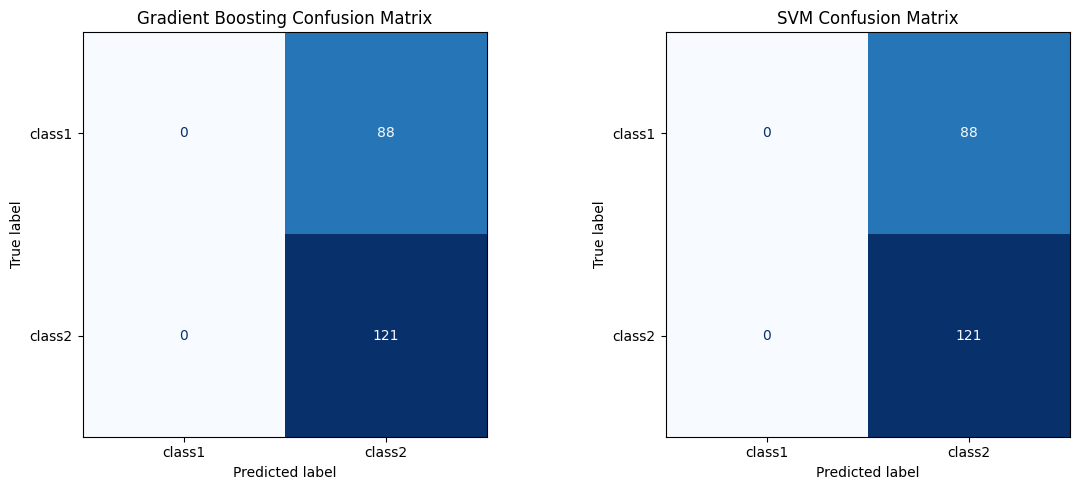

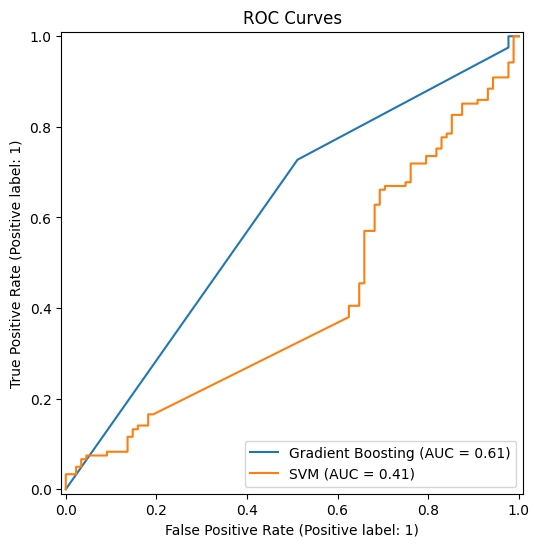

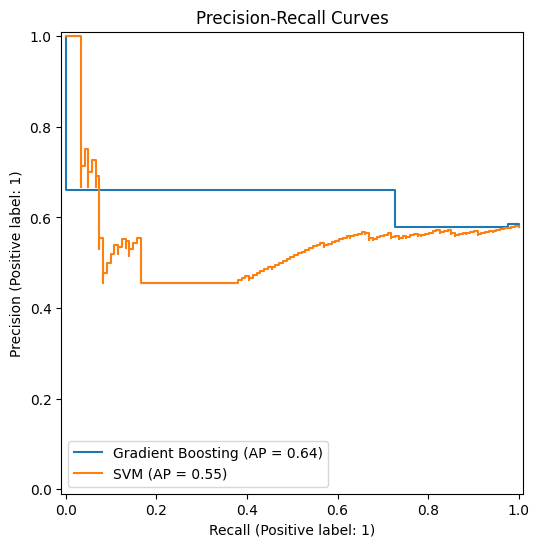

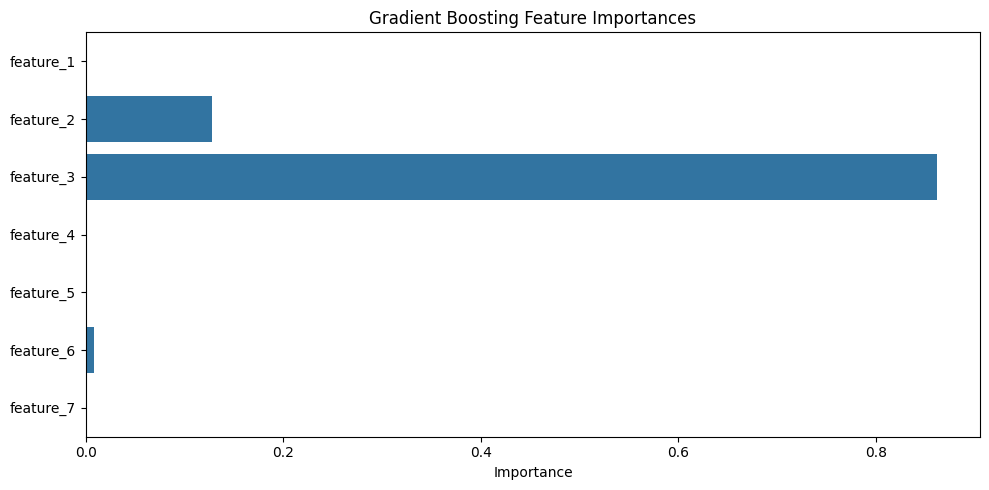

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report,
)

# Use the same test set from your notebook
y_pred_gb = best_gb.predict(X_test_scaled)
y_score_gb = best_gb.predict_proba(X_test_scaled)[:, 1]

y_pred_svc = best_svc.predict(X_test_scaled)
y_score_svc = best_svc.decision_function(X_test_scaled)

# Classification reports
print("Gradient Boosting classification report:")
print(classification_report(y_test, y_pred_gb, digits=4))
print("SVM classification report:")
print(classification_report(y_test, y_pred_svc, digits=4))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, title in zip(
    axes,
    [y_pred_gb, y_pred_svc],
    ["Gradient Boosting", "SVM"],
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["class1", "class2"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{title} Confusion Matrix")
plt.tight_layout()
plt.show()

# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test, y_score_gb, name="Gradient Boosting", ax=ax
)
RocCurveDisplay.from_predictions(
    y_test, y_score_svc, name="SVM", ax=ax
)
ax.set_title("ROC Curves")
plt.show()

# Precision-Recall curves
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(
    y_test, y_score_gb, name="Gradient Boosting", ax=ax
)
PrecisionRecallDisplay.from_predictions(
    y_test, y_score_svc, name="SVM", ax=ax
)
ax.set_title("Precision-Recall Curves")
plt.show()

# Feature importances for Gradient Boosting
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    x=best_gb.feature_importances_,
    y=[f"feature_{i+1}" for i in range(best_gb.feature_importances_.shape[0])],
    ax=ax,
)
ax.set_title("Gradient Boosting Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## **3. Reflection and Discussion**n
## Part 1 

### Model Performance
Logistic Regression achieved an average accuracy of **0.9386**, while Naive Bayes achieved **0.9264**.

### Analysis
The better performance of Logistic Regression can be attributed to its ability to model relationships between features, whereas Naive Bayes assumes that all features are independent. In this dataset, features such as area and perimeter are likely correlated, which negatively impacts Naive Bayes.

### Model Comparison
- **Logistic Regression**: More flexible, captures feature relationships, higher accuracy  
- **Naive Bayes**: Simpler, faster, but assumes feature independence  

### Conclusion
Logistic Regression performed better overall, while Naive Bayes remains a computationally efficient alternative.



## **AI Acknowledgement**

This notebook used AI assistance to implement Gradient Boosting and SVM, including cross-validation, hyperparameter tuning, and test-set evaluation